## Import Libraries

In [506]:
import pandas as pd
import matplotlib.pyplot as plt

## Read and Explore a CSV File

In [507]:
df = pd.read_csv('../data/jobs_snapshot.csv')

In [508]:
df.head(1)

,company,adref,salary_is_predicted,id,__CLASS__,category,description,title,created,redirect_url,location,longitude,latitude,contract_time,contract_type,salary_max,salary_min
0,{'__CLASS__': 'Adzuna::API::Response::Company'...,eyJhbGciOiJIUzI1NiJ9.eyJzIjoia05QUDNDbGY4UkdaR...,0,5736315501,Adzuna::API::Response::Job,"{'tag': 'unknown', '__CLASS__': 'Adzuna::API::...",Mit innovativen Seilbahnen sorgen die Doppelma...,Projektleiter:in im Bereich AI-Data,2026-05-21T11:48:08Z,https://www.adzuna.de/land/ad/5736315501?se=kN...,"{'area': ['Deutschland'], 'display_name': 'Deu...",NaN,NaN,NaN,NaN,NaN,NaN


Non-numeric json objects correspond to dictionary in Python. They were converted into strings after loading. For further analysis, to extract information from key-value pairs, they should be converted back to dictionaries.

In [509]:
df.columns

Index(['company', 'adref', 'salary_is_predicted', 'id', '__CLASS__',
       'category', 'description', 'title', 'created', 'redirect_url',
       'location', 'longitude', 'latitude', 'contract_time', 'contract_type',
       'salary_max', 'salary_min'],
      dtype='str')

In [510]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4323 entries, 0 to 4322
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   company              4323 non-null   str    
 1   adref                4323 non-null   str    
 2   salary_is_predicted  4323 non-null   int64  
 3   id                   4323 non-null   int64  
 4   __CLASS__            4323 non-null   str    
 5   category             4323 non-null   str    
 6   description          4323 non-null   str    
 7   title                4323 non-null   str    
 8   created              4323 non-null   str    
 9   redirect_url         4323 non-null   str    
 10  location             4323 non-null   str    
 11  longitude            3478 non-null   float64
 12  latitude             3478 non-null   float64
 13  contract_time        2258 non-null   str    
 14  contract_type        509 non-null    str    
 15  salary_max           170 non-null    float64
 16 

This data is quite complete. All fields relevant to the analysis, apart from those containing salary data, are nor empty.

Non-numeric fiels are of type 'str'.

Numeric field are of types 'int' and 'float64'.

In [511]:
df['description'].iloc[0]

'Mit innovativen Seilbahnen sorgen die Doppelmayr-Teams für Weltrekorde, auffällige Highlights und Begeisterung bei Kunden und Fahrgästen. Wir entwickeln Mobilitätslösungen für die Zukunft und leistungsfähige Materialtransportsysteme für den Einsatz auf der ganzen Welt. Möglich machen das unsere Mitarbeiter:innen, die unsere einzigartigen Projekte umsetzen und mit innovativen Ideen immer wieder für Begeisterung sorgen. Für den Bereich IT & Business Process Management in der Doppelmayr Seilbahnen…'

The description of each job post is being loaded in a limitied version - with 500 characters at the begining of the text. This is the limit set by API. There is no possibilities to obtain such information from the description as: the requirements to language levels and tech skills. Therefore, the further research will be focused on analysing job titles, salary, companies, and location - data that can be received from other fields.

## Key Metrics

In [512]:
print(f'Total amount of job posts found: {len(df)}')

Total amount of job posts found: 4323


The data downloaded from API contains all jobs with the word 'data' in their title and description. 

In [513]:
print(f'Number of unique job titles: {df['title'].nunique()}')

Number of unique job titles: 2577


In [514]:
df.title.unique()[:100]

<StringArray>
[                                                               'Projektleiter:in im Bereich AI-Data',
                                                                    'Praktikum Panel Data Management',
                                               'Praktikum Personal - Data Management & Authorization',
                                                                             'Data Architect (m/w/d)',
                                                                   'Data Analyst (M/W/D) Procurement',
                                                               'Projektleiter:in (m/w/d) Data Center',
                                           'Duales Studium Wirtschaftsinformatik - Data Science 2027',
                                                                  'Lead Consultant Data & AI (m/w/d)',
                                                             'Senior Data Engineer (m/w/d) Snowflake',
                                                       'Eng

The data includes different data positions, such as Data Engineer, Data Architect, Data Migration Developer, as well as non-data positions, such as Legal Counsel Data Privacy. In our research, we will be only focusing on Data Anlyst positions.

#### Companies

In [515]:
df['company'].notna().sum()

np.int64(4323)

In [516]:
type(df["company"].iloc[0])

str

In [517]:
df["company"].iloc[0]

"{'__CLASS__': 'Adzuna::API::Response::Company', 'display_name': 'Doppelmayr Seilbahnen GmbH'}"

The field 'company' has type 'str' and looks like a dictionary. To extract a company's name, it is necessary to convert a string into dictionary and take the value of the key 'display_name'.

In [518]:
import ast  # Abstract Syntax Trees

df['company_dict'] = df['company'].apply(ast.literal_eval) #convert str to dict
df['company_name'] = df['company_dict'].apply(lambda x: x.get('display_name'))  #take the company name
df['company_name'].iloc[0]

'Doppelmayr Seilbahnen GmbH'

ast is a Python library. 
ast.literal_eval is a function that parses text literarly, according to Python syntax. If it identifies curly brackets { }, is converts the text into a dictionary. If it identifies square brackets [ ], it converts the text into a list.

#### Location

In [519]:
type(df['location'].iloc[0])

str

In [520]:
df['location'].iloc[5]

"{'area': ['Deutschland', 'Hessen', 'Frankfurt am Main'], 'display_name': 'Frankfurt am Main, Hessen', '__CLASS__': 'Adzuna::API::Response::Location'}"

The 'location' field is of type 'str' and should be converted into a dictionary.

In [521]:
df['location'] = df['location'].apply(lambda x: ast.literal_eval(x) if pd.notnull(x) else {})

#take the value of the key 'display_name'
df['location_name'] = df['location'].apply(lambda x: x.get('display_name'))
df['location_name'].iloc[0]

'Deutschland'

In [522]:
#split location_name to get city as a first part before comma, then delete spaces
df['city'] = df['location_name'].str.split(',').str[0].str.strip()
print(sorted(df['city'].dropna().unique()))

['Aachen', 'Aachen (Kreis)', 'Aalen', 'Abraham', 'Adlershof', 'Ahaus', 'Ahrensburg', 'Albstadt', 'Aletshausen', 'Allach-Untermenzing', 'Alsfeld', 'Alsterdorf', 'Alt-Langenhagen', 'Altenbochum', 'Altendorf', 'Altengamme', 'Altenlingen', 'Altgefäll', 'Altmarkkreis Salzwedel', 'Altona-Altstadt', 'Altona-Nord', 'Altstadt', 'Altstadt-Lehel', 'Altstadt-Mitte', 'Altstadt-Nord', 'Altstadt-Süd', 'Am Sandkopf', 'Am Schöt', 'Amerang', 'Ammerbach', 'Anger', 'Ansbach', 'Antonsviertel', 'Arheilgen', 'Arlinger', 'Arnsberg', 'Aschaffenburg', 'Aschheim', 'Attendorn', 'Au-Haidhausen', 'Aubing-Lochhausen-Langwied', 'Augsburg', 'Augsburg (Kreis)', 'Aurich', 'Babelsberg Süd', 'Bad Buchau', 'Bad Cannstatt', 'Bad Friedrichshall', 'Bad Godesberg', 'Bad Hersfeld', 'Bad Homburg', 'Bad Homburg vor der Höhe', 'Bad Honnef', 'Bad Kissingen', 'Bad Neustadt an der Saale', 'Bad Oeynhausen', 'Bad Salzuflen', 'Bad Salzungen', 'Bad Säckingen', 'Bad Vilbel', 'Bad Wilhelmshöhe', 'Baden-Baden', 'Baden-Württemberg', 'Bahnhof

In [523]:
# combine neighbourhoods into cities
neighbourhoods_to_cities = {
    'Mitte': 'Berlin',      # Berlin
    'Moabit': 'Berlin',
    'Tiergarten': 'Berlin',
    'Charlottenburg': 'Berlin',
    'Prenzlauer Berg': 'Berlin',
    'Kreuzberg': 'Berlin',
    'Neukölln': 'Berlin',
    'Wedding': 'Berlin',
    'Friedrichshain': 'Berlin',
    'Wilmersdorf': 'Berlin',
    'Adlershof': 'Berlin',
    'Britz': 'Berlin',
    'Biesdorf': 'Berlin',
    'Lichtenberg': 'Berlin',
    'Altstadt-Lehel': 'München',   # München
    'Maxvorstadt': 'München',
    'Ludwigsvorstadt-Isarvorstadt': 'München',
    'Schwabing-Freimann': 'München',
    'Sendling': 'München',
    'Bogenhausen': 'München',
    'Berg am Laim': 'München',
    'Obergiesing': 'München',
    'Milbertshofen-Am Hart': 'München',
    'Moosach': 'München',
    'Laim': 'München',
    'Au-Haidhausen': 'München',
    'Untergiesing-Harlaching': 'München',
    'Feldmoching-Hasenbergl': 'München',
    'Allach-Untermenzing': 'München',
    'Hamburg-Altstadt': 'Hamburg',      # Hamburg
    'Altona-Altstadt': 'Hamburg',
    'Altona-Nord': 'Hamburg',
    'Ottensen': 'Hamburg',
    'HafenCity': 'Hamburg',
    'Hammerbrook': 'Hamburg',
    'Harvestehude': 'Hamburg',
    'Wilhelmsburg': 'Hamburg',
    'Alsterdorf': 'Hamburg',
    'Barmbek-Süd': 'Hamburg',
    'Bramfeld': 'Hamburg',
    'Billwerder': 'Hamburg',
    'Finkenwerder': 'Hamburg',
    'Langenhorn': 'Hamburg',
    'Ehrenfeld': 'Köln',     # Köln
    'Deutz': 'Köln',
    'Junkersdorf': 'Köln',
    'Bickendorf': 'Köln',
    'Bayenthal': 'Köln',
    'Braunsfeld': 'Köln',
    'Gallus': 'Frankfurt am Main',      # Frankfurt
    'Rödelheim': 'Frankfurt am Main',
    'Bonames': 'Frankfurt am Main',
    'Dornbusch': 'Frankfurt am Main',
    'Heddernheim': 'Frankfurt am Main',
    'Fechenheim': 'Frankfurt am Main',
    'Bockenheim': 'Frankfurt am Main',
    'Flingern Nord': 'Düsseldorf',       # Düsseldorf
    'Golzheim': 'Düsseldorf',
    'Hubbelrath': 'Düsseldorf',
    'Unterbach': 'Düsseldorf',
    'Lörick': 'Düsseldorf',
    'Düsseltal': 'Düsseldorf',
    'Bothfeld': 'Hannover',   # Hannover
    'Bemerode': 'Hannover',
    'Döhren': 'Hannover',
    'Ricklingen': 'Hannover',
    'List': 'Hannover',
    'Bult': 'Hannover',
    'Galgenhof': 'Nürnberg',   # Nürnberg
    'Gleißbühl': 'Nürnberg',
    'Gebersdorf': 'Nürnberg',
    'Eibach': 'Nürnberg',
    'Kleinreuth h d Veste': 'Nürnberg',
    'Schoppershof': 'Nürnberg'
}

df['city'] = df['city'].replace(neighbourhoods_to_cities)

In [524]:
print(sorted(df['city'].dropna().unique()))

['Aachen', 'Aachen (Kreis)', 'Aalen', 'Abraham', 'Ahaus', 'Ahrensburg', 'Albstadt', 'Aletshausen', 'Alsfeld', 'Alt-Langenhagen', 'Altenbochum', 'Altendorf', 'Altengamme', 'Altenlingen', 'Altgefäll', 'Altmarkkreis Salzwedel', 'Altstadt', 'Altstadt-Mitte', 'Altstadt-Nord', 'Altstadt-Süd', 'Am Sandkopf', 'Am Schöt', 'Amerang', 'Ammerbach', 'Anger', 'Ansbach', 'Antonsviertel', 'Arheilgen', 'Arlinger', 'Arnsberg', 'Aschaffenburg', 'Aschheim', 'Attendorn', 'Aubing-Lochhausen-Langwied', 'Augsburg', 'Augsburg (Kreis)', 'Aurich', 'Babelsberg Süd', 'Bad Buchau', 'Bad Cannstatt', 'Bad Friedrichshall', 'Bad Godesberg', 'Bad Hersfeld', 'Bad Homburg', 'Bad Homburg vor der Höhe', 'Bad Honnef', 'Bad Kissingen', 'Bad Neustadt an der Saale', 'Bad Oeynhausen', 'Bad Salzuflen', 'Bad Salzungen', 'Bad Säckingen', 'Bad Vilbel', 'Bad Wilhelmshöhe', 'Baden-Baden', 'Baden-Württemberg', 'Bahnhofsviertel', 'Bahrenfeld', 'Bakum', 'Balingen', 'Bamberg', 'Barbaraviertel', 'Bargteheide', 'Barkhausen', 'Barleben', 'Ba

In [525]:
# exclude Germany and lands in cities
exclude_locations = [
    'Deutschland',
    'Bayern',
    'Baden-Württemberg',
    'Nordrhein-Westfalen',
    'Saarland',
    'Sachsen'
]

df = df[~df['city'].isin(exclude_locations)]

In [526]:
print(sorted(df['city'].dropna().unique()))

['Aachen', 'Aachen (Kreis)', 'Aalen', 'Abraham', 'Ahaus', 'Ahrensburg', 'Albstadt', 'Aletshausen', 'Alsfeld', 'Alt-Langenhagen', 'Altenbochum', 'Altendorf', 'Altengamme', 'Altenlingen', 'Altgefäll', 'Altmarkkreis Salzwedel', 'Altstadt', 'Altstadt-Mitte', 'Altstadt-Nord', 'Altstadt-Süd', 'Am Sandkopf', 'Am Schöt', 'Amerang', 'Ammerbach', 'Anger', 'Ansbach', 'Antonsviertel', 'Arheilgen', 'Arlinger', 'Arnsberg', 'Aschaffenburg', 'Aschheim', 'Attendorn', 'Aubing-Lochhausen-Langwied', 'Augsburg', 'Augsburg (Kreis)', 'Aurich', 'Babelsberg Süd', 'Bad Buchau', 'Bad Cannstatt', 'Bad Friedrichshall', 'Bad Godesberg', 'Bad Hersfeld', 'Bad Homburg', 'Bad Homburg vor der Höhe', 'Bad Honnef', 'Bad Kissingen', 'Bad Neustadt an der Saale', 'Bad Oeynhausen', 'Bad Salzuflen', 'Bad Salzungen', 'Bad Säckingen', 'Bad Vilbel', 'Bad Wilhelmshöhe', 'Baden-Baden', 'Bahnhofsviertel', 'Bahrenfeld', 'Bakum', 'Balingen', 'Bamberg', 'Barbaraviertel', 'Bargteheide', 'Barkhausen', 'Barleben', 'Barmen', 'Barsinghausen

#### Filtering Data Analyst vacancies

For filtering, we use several key words and phrases in English and German:
- data analyst,
- daten analyst,
- datenanalyst.

In [527]:
#only data analyst
data_analyst_jobs = df[df['title'].str.contains('data analyst|daten analyst|datenanalyst', case=False, na=False)]
# filter out education
data_analyst_jobs = data_analyst_jobs[~data_analyst_jobs['title'].str.contains('weiterbildung|bildungsgutschein', case=False, na=False)]

print(f'Data Analyst positions: {len(data_analyst_jobs)}')

Data Analyst positions: 223


#### The distribution of vacancies by seniority

Key words and phrases for junior positions: juior, entry level, trainee, etc.

In [528]:
junior_data_analyst_jobs = data_analyst_jobs[data_analyst_jobs['title'].str.contains('junior|entry level|trainee|praktikant|graduate|einsteiger', case=False)]
print(f'Junior data analyst positions: {len(junior_data_analyst_jobs)}')

Junior data analyst positions: 11


Key words and phrases for senior positions: senior, lead, leiter, expert, etc.

In [529]:
senior_data_analyst_jobs = data_analyst_jobs[data_analyst_jobs['title'].str.contains('senior|lead|principal|head|manager|director|leiter|leitung|teamleiter|projektleiter|expert', case=False)]
print(f'Senior data anlyst positions: {len(senior_data_analyst_jobs)}')

Senior data anlyst positions: 55


In [530]:
middle_data_analyst_jobs = data_analyst_jobs[
    ~data_analyst_jobs.index.isin(senior_data_analyst_jobs.index)
    & ~data_analyst_jobs.index.isin(junior_data_analyst_jobs.index)
]
print(f'Middle or undefined data analyst positions: {len(middle_data_analyst_jobs)}')

Middle or undefined data analyst positions: 157


#### The availability of information about salary

In [531]:
#prepare salary columns for quantitative analysis

data_analyst_jobs['salary_max'].notnull().sum()

np.int64(17)

In [532]:
data_analyst_jobs["salary_min"].notnull().sum()

np.int64(17)

In [533]:
jobs_with_salary = data_analyst_jobs[data_analyst_jobs["salary_min"].notnull() | data_analyst_jobs["salary_max"].notnull()]
print(f'Only {len(jobs_with_salary)} out of {len(data_analyst_jobs)} job vacancies have salary information.')

Only 17 out of 223 job vacancies have salary information.


Few job postings have information about minimum and maximum salary, which indicates a lack of transparancy from employers and recruiting companies on this point.

#### Identifying a salary range for Data Analyst vacancies

In [534]:
#Preview of salary columns
salary_min = data_analyst_jobs['salary_min'].min()
print(data_analyst_jobs.sort_values('salary_min').head(5)[['title', 'salary_min']])

                                                  title  salary_min
1978               (Senior) Energy Data Analyst (d/f/m)        80.0
521                   Data Analyst / Data Engineer (gn)     55000.0
3633  Business / Data Analyst Power BI & Microsoft F...     55000.0
1505                         Data Analyst (m/w/d) Sales     60000.0
1741                        Senior Data Analyst (m/w/d)     60000.0


In [535]:
salary_max = data_analyst_jobs['salary_max'].max()
print(data_analyst_jobs.sort_values('salary_max').head(5)[['title', 'salary_max']])

                                                  title  salary_max
1978               (Senior) Energy Data Analyst (d/f/m)       100.0
521                   Data Analyst / Data Engineer (gn)     65000.0
3633  Business / Data Analyst Power BI & Microsoft F...     65000.0
1505                         Data Analyst (m/w/d) Sales     68000.0
1741                        Senior Data Analyst (m/w/d)     75000.0


Some records have salary per hour, which can create a misleading result. The annual salary starts with a five-digit number, a condition should be applied that the minimum salary is equal or more than 10000. Thus, a salary per hour is excluded from the analysis.

In [536]:
annual_salary = data_analyst_jobs[(data_analyst_jobs['salary_min'] >= 10000) & (data_analyst_jobs['salary_max'] >= 10000)].copy()

In [537]:
#average salary
annual_salary['salary_avg'] = (annual_salary['salary_min'] + annual_salary['salary_max']) / 2
annual_salary['salary_avg'].describe()

count        16.000000
mean      89511.281250
std       32936.387015
min       60000.000000
25%       67500.000000
50%       76240.250000
75%      102500.000000
max      178100.000000
Name: salary_avg, dtype: float64

In [538]:
annual_salary_min = annual_salary['salary_min'].min()
print(f'The lowest annual salary of Data Analyst positions is: {annual_salary_min}')

The lowest annual salary of Data Analyst positions is: 55000.0


In [539]:
annual_salary_max = annual_salary['salary_max'].max()
print(f'The highest annual salary of Data Analyst positions is : {annual_salary_max}')

The highest annual salary of Data Analyst positions is : 187200.0


In [540]:
salary_avg = annual_salary['salary_avg'].dropna()
salary_avg

483      80000.0
521      60000.0
557      70000.0
714     117500.0
1099     70000.0
1308    117500.0
1505     64000.0
1628     67500.0
1662    136500.0
1663    178100.0
1689     77500.0
1741     67500.0
2157     97500.0
2830     74980.5
3493     93600.0
3633     60000.0
Name: salary_avg, dtype: float64

In [541]:
salary_avg.mean()

np.float64(89511.28125)

In [542]:
salary_avg.median()

np.float64(76240.25)

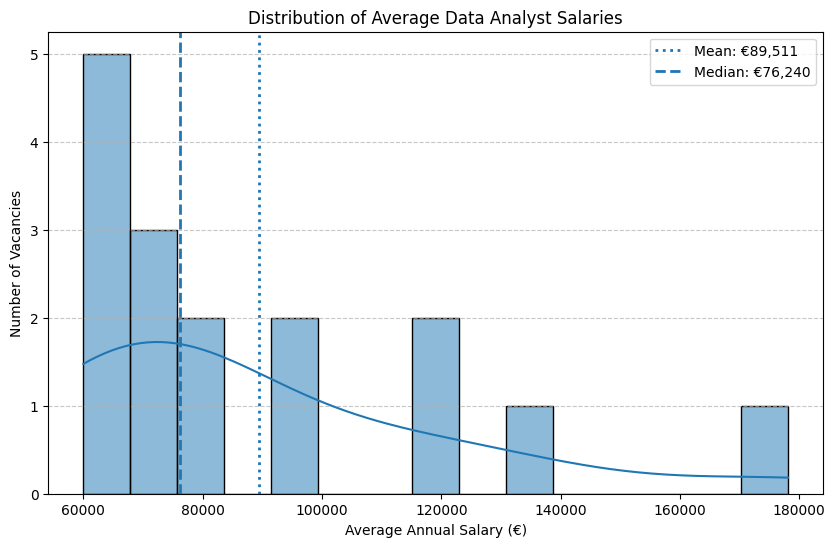

In [543]:
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.histplot(
    salary_avg,
    bins=15,
    kde=True
)

mean_salary = salary_avg.mean()
median_salary = salary_avg.median()

plt.axvline(
    mean_salary,
    linestyle=':',
    linewidth=2,
    label=f'Mean: €{mean_salary:,.0f}'
)

plt.axvline(
    median_salary,
    linestyle='--',
    linewidth=2,
    label=f'Median: €{median_salary:,.0f}'
)

plt.legend()

plt.title('Distribution of Average Data Analyst Salaries')
plt.xlabel('Average Annual Salary (€)')
plt.ylabel('Number of Vacancies')

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.savefig( '../visuals/salary_distribution.png',bbox_inches='tight', dpi=300)

plt.show()

The distribution of average salaries is right-skewed. Several highly-paid positions pull the average salary for Data Analyst roles to the right. Therefore, for this dataset, it is better to use median value as an average salary.

#### Creating a DataFrame with key metrics for a dashboard in Power BI

In [544]:
key_metrics = pd.DataFrame([{
    'Total Jobs': len(df), 
    'Data Analyst Jobs': len(data_analyst_jobs),
    'Junior Data Analyst Jobs': len(junior_data_analyst_jobs),
    'Middle Data Analyst Jobs': len(middle_data_analyst_jobs),
    'Senior Data Analyst Jobs': len(senior_data_analyst_jobs),
    'Jobs with Salary Information': len(jobs_with_salary),
    'Lowest Annual Salary': int(annual_salary_min),
    'Highest Annual Salary': int(annual_salary_max),
    'Average Salary': int(salary_avg.mean())
}])

key_metrics.to_csv('../dashboard/key_metrics.csv', index=False)


#### Top companies

In [545]:
top_companies = data_analyst_jobs['company_name'].value_counts().head(5).reset_index()
top_companies.columns = ['company_name', 'job_postings']
print(f'Top 5 companies with the most Data Analystjob postings: {top_companies}')

Top 5 companies with the most Data Analystjob postings:                   company_name  job_postings
0           KIND GmbH & Co. KG            15
1             KNDS Deutschland             8
2             Redcare Pharmacy             6
3  ISR Information Products AG             5
4                        Serco             4


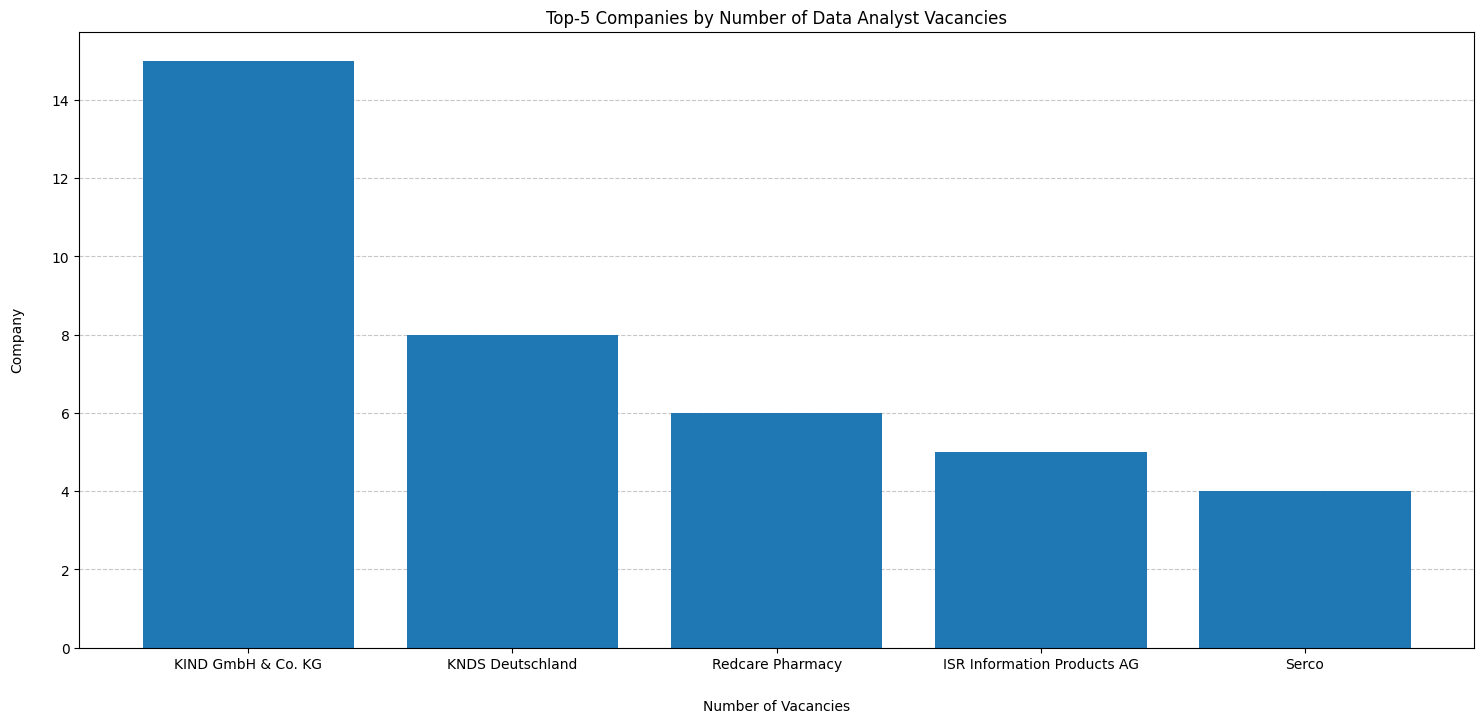

In [546]:
companies = top_companies['company_name']
counts = top_companies['job_postings']

plt.figure(figsize=(18, 8))
plt.bar(companies, counts)  #top-5 companies with the most jobs postings

plt.title('Top-5 Companies by Number of Data Analyst Vacancies')
plt.xlabel('Number of Vacancies', labelpad=20)
#plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.gca().set_axisbelow(True)
plt.ylabel('Company', labelpad=20)

plt.savefig('../visuals/top_companies_by_vacancies.png', bbox_inches='tight', dpi=300)

plt.show()

4 of 5 top-5 companies provide IT services and products. One is a recruitment agency working in German, Austrian and Swiss job market.

In [547]:
# save to csv for Power BI dashboard
top_companies.to_csv('../dashboard/top_companies.csv', index=False)

#### Top cities

In [548]:
top_cities = (
    data_analyst_jobs['city']
    .value_counts()
    .head(6)
    .reset_index()
)
print(f'Top 6 cities by number of vacancies: {top_cities}')

Top 6 cities by number of vacancies:                 city  count
0             Berlin     43
1            München     21
2            Hamburg     19
3               Köln     12
4  Frankfurt am Main      9
5         Düsseldorf      7


In [549]:
top_cities.columns = ['city', 'job_postings']

<Figure size 1000x600 with 0 Axes>

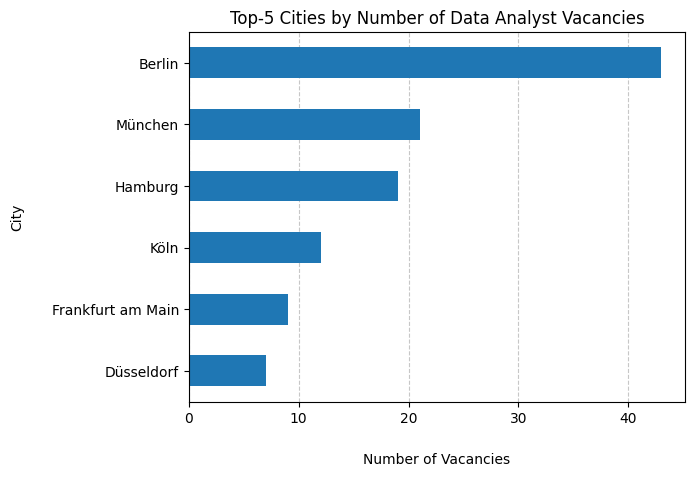

In [550]:
plt.figure(figsize=(10, 6))
top_cities.sort_values(by='job_postings').plot(
    x='city',
    y='job_postings',
    kind='barh',
    legend=False
)  #with the city with the most jobs postings at the top

plt.title('Top-5 Cities by Number of Data Analyst Vacancies')
plt.xlabel('Number of Vacancies', labelpad=20)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.gca().set_axisbelow(True)
plt.ylabel('City', labelpad=20)

plt.savefig('../visuals/top_cities_by_vacancies.png', bbox_inches='tight', dpi=300)

plt.show()

In [551]:
#save to csv for Power BI dashboard
top_cities.to_csv('../dashboard/top_cities.csv', index=False)

## Analysis, Identification of Relationships, and Visualisation

#### Junior Data Analyst roles

In [552]:
junior_salary_min = junior_data_analyst_jobs['salary_min'].min()
print(f'The lowest annual salary of junior Data Analyst positions is: {junior_salary_min}')

The lowest annual salary of junior Data Analyst positions is: nan


In [553]:
junior_salary_max = junior_data_analyst_jobs['salary_max'].max()
print(f'The highest annual salary of junior Data Analyst positions is: {junior_salary_max}')

The highest annual salary of junior Data Analyst positions is: nan


The salary information for junior Data Analyst positions is unavailable.

In [554]:
senior_data_analyst_jobs['company_name'].value_counts().head(5)

company_name
ISR Information Products AG    5
exmox                          3
21strategies GmbH              2
getolo GmbH                    2
RELX INC                       2
Name: count, dtype: int64

#### Average salary by companies

In [555]:
avg_salary_by_company = (
    annual_salary
    .groupby('company_name')['salary_avg']
    .agg(['mean', 'count'])
    .reset_index()
)

top_5_companies = avg_salary_by_company.sort_values('mean', ascending=False).head(5)
top_5_companies

,company_name,mean,count
3,N Consulting Ltd,157300.0,2
5,Quince,117500.0,2
1,Flexa,97500.0,1
7,Trenkwalder Deutschland,93600.0,1
4,Peak One GmbH,80000.0,1


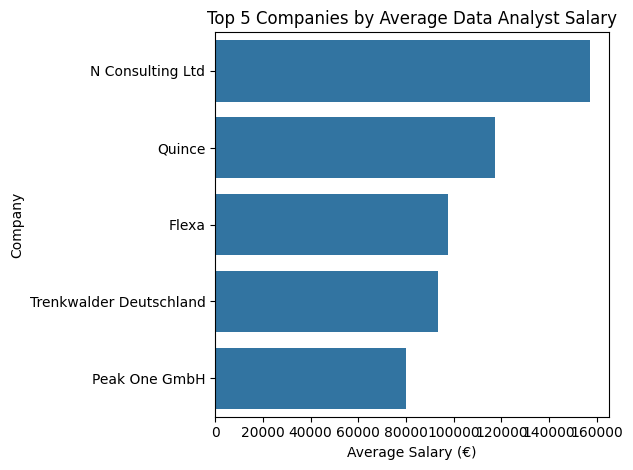

In [556]:
sns.barplot(
    data=top_5_companies,
    x='mean',
    y='company_name'
)

plt.xlabel('Average Salary (€)')
plt.ylabel('Company')
plt.title('Top 5 Companies by Average Data Analyst Salary')

plt.tight_layout()

plt.savefig('../visuals/top_companies_by_salary.png', bbox_inches='tight', dpi=300)

plt.show()